# Homework03

Some exercises with `JSON` files, `Python` dicts/objects, and functions.

## Goals

- Get familiar with Python's notation for lists and objects
- Experiment with Python's unique functionalities for processing lists and objects
- Learn to load and process `JSON` files using Python

### Setup

Run the following 2 cells to import all necessary libraries and helpers for Homework 03

In [5]:
!wget -q https://github.com/PSAM-5005-2026S-A/5005-utils/raw/main/src/data_utils.py

In [6]:
from Homework03_utils import Tests
from data_utils import image_from_url, list_from_csv_url, object_from_json_url

### Exercise 01: Warm Up

Working with lists and dictionaries/objects.

Write a function `sum_objects(in_list)` that accept a list of objects and returns a sum according to the following specifications:

Each object in the list has 2 fields, `type` and `amount`, and so will look something like this:

```python
test_list = [
  { "type": "cost", "amount": 10.00 },
  { "type": "cost", "amount": 20.00 },
  { "type": "income", "amount": 100.50 },
  { "type": "income", "amount": 240.00 },
]
```

The `sum_objects(in_list)` function should iterate through all of the items in `in_list` and sum the `amount` values using positive numbers when `type` is `"income"`, and negative numbers when `type` is `"cost"`.

For example, passing the above list to the function should return $310.50$.

The `"type"` for each object is always `"cost"` or `"income"`, so if it's not `"cost"` it has to be `"income"`. This means a single `if`/`else` statement inside a `for` loop, to check whether `type == "cost"`, should be enough to account for both cases.

In [ ]:
# Implement 01 here

def sum_objects(in_list):
    total = 0
    for item in in_list:
        if item["type"] == "income":
            total += item["amount"]
        elif item["type"] == "cost":
            total -= item["amount"]
    return total


In [7]:
# Run this cell to test if function returns 310.50

test_list = [
  { "type": "cost", "amount": 10.00 },
  { "type": "cost", "amount": 20.00 },
  { "type": "income", "amount": 100.50 },
  { "type": "income", "amount": 240.00 },
]

sum_objects(test_list)

310.5

In [8]:
# Run this cell to test if function returns 345.67

test_list = [
  { "type": "cost", "amount": 14.11 },
  { "type": "cost", "amount": 35.99 },
  { "type": "income", "amount": 152.25 },
  { "type": "income", "amount": 243.52 },
]

sum_objects(test_list)

345.67

#### Exercise 01 test:

Run the following cell to test the `sum_objects()` function.

In [9]:
# Test 01
Tests.test("01", sum_objects)

01: All tests passed 🎉🎉🎉


### Exercise 02:

Working with data files.

Find the name and population of the 3 cities that are geographically closest to the world's most populous city.

# 🤔😱


#### Load Data:

Let's break this down into a few sub-problems.

First, let's load a JSON file that has information about large cities in the world.

The file at this [URL](https://raw.githubusercontent.com/PSAM-5020-2025S-A/5020-utils/main/datasets/json/cities50k.json) has a list of cities formatted like this:

```py
{
  "name": "Pittsburgh",
  "country": "US",
  "admin1": "Pennsylvania",
  "lat": 40.4406200,
  "lon": -79.9958900,
  "pop": 304391
}
```

This is similar to how we loaded the wine and ansur data files in class, but we're going to use a helper function `object_from_json_url()` that takes care of downloading, opening and loading a `json` file into a `Python` list/object when given an URL.

In [21]:
# Define the location of the json file here
CITIES_FILE = "https://raw.githubusercontent.com/PSAM-5005-2026S-A/5005-utils/main/datasets/json/cities.json"

# Use the object_from_json_url() function to load contents from 
# the json file into a Python object called "info_cities"


import requests

def object_from_json_url(url):
    response = requests.get(url)
    response.raise_for_status()
    return response.json()

CITIES_FILE = "https://raw.githubusercontent.com/PSAM-5005-2026S-A/5005-utils/main/datasets/json/cities.json"

info_cities = object_from_json_url(CITIES_FILE)

#### Exercise 02A:

Ok. We should now have a list of objects with information about cities.

Explore the data and answer the following questions:
- How many cities are in this list?
- What's the name of the first city on the list?
- What are the latitude and longitude of the last city on the list?
- What are the populations for the largest and smallest cities?
- What's the name of the city with the largest population?


In [ ]:
# Work on 02A here

# How many cities are in the list?


num_cities = 0

num_cities = len(info_cities)
print("Number of cities:", num_cities)




Number of cities: 8670
First city name: Abu Dhabi


In [ ]:


# What's the name of the first city on the list?

first_city = ""

first_city_name = info_cities[0]['name']
print("First city name:", first_city_name)


First city name: Abu Dhabi


In [13]:

# What are the latitude and longitude of the last city on the list?

last_latitude = 0
last_longitude = 0

last_latitude = info_cities[11]['lat']
print("last city latitude:", last_latitude)
last_longitude = info_cities[11]['lon']
print("last city longitude:", last_longitude)


last city latitude: 25.33737
last city longitude: 55.41206


In [ ]:



# What are the populations for the largest and smallest cities?


populations = [city['pop'] for city in info_cities]
largest_population = max(populations)
smallest_population = min(populations)

print("Largest populations:", largest_population) 
print("Smallest populations:", smallest_population)




Largest populations: 22315474
Smallest populations: 50011


In [5]:


# What's the name of the city with the largest population?



populations = [city['pop'] for city in info_cities]
largest_population = max(populations)

for city in info_cities:
    if city['pop'] == largest_population:
        largest_city_name = city['name']

print("largest_city_name:", largest_city_name)





largest_city_name: Shanghai


#### Test 02A

In [20]:
# Test 02A
answers = [8670, "Abu Dhabi", 25.33737, 55.41206, 22315474, 50011, "Shanghai"]

Tests.test("02A", answers)



ERROR Check last_latitude. It should be smaller than 25.33737
ERROR Check last_longitude. It should be smaller than 55.41206


#### Exercise 02B:

We have the largest city's name and population, but we need its location (lat/lon).

We can recycle some of the logic from above to get the whole object that contains information for the largest city.

In [17]:
# Work on 02B here

largest_city = {}

In [ ]:
# Test 02B
Tests.test("02B", largest_city)

#### Exercise 02C:

We should have all info about the largest city here.

Now, we'll iterate through the list and use each city's latitude and longitude to calculate its distance from the largest city.

Althought not $100\%$ correct, it's ok to use the [2D Euclidean distances](https://en.wikipedia.org/wiki/Euclidean_distance#Two_dimensions) for this.

Could be useful to define a function `distance(cityA, cityB)` that receives objects with info for $2$ cities and returns the distance between them.

In [24]:

import math

def distance(cityA, cityB):
 
    dx = cityA['lat'] - cityB['lat']
    dy = cityA['lon'] - cityB['lon']
    return math.sqrt(dx**2 + dy**2)

city1 = info_cities[0]
city2 = info_cities[1]

print(distance(city1, city2))

1.4401235573727684


In [25]:
# Test 02C
Tests.test("02C", distance)

02C: All tests passed 🎉🎉🎉


#### Exercise 02D:

Ok. We implemented a function to calculate the distance between 2 cities, let's use it now.

Iterate through the list of cities again, calculate the distance from each city to the largest city, and add that as a new feature/key to each city's entry:

```py
{
  "name": "Pittsburgh",
  "country": "US",
  "admin1": "Pennsylvania",
  "lat": 40.4406200,
  "lon": -79.9958900,
  "pop": 304391,
  "distance": 1222.32
}
```

Just make sure the key that holds the distance value is called `distance`.

In [27]:
# Work on 02D here

# Now calculate every city's distance from the largest city and
# add that info to each city's entry

import math
largest_city = max(info_cities, key=lambda city: city['pop'])

for city in info_cities:
    city['distance_from_largest'] = distance(city, largest_city)

distances = [city['distance_from_largest'] for city in info_cities]
print(distances)

[67.40206314269321, 66.235511831048, 66.0726126284749, 65.40228606844411, 67.09874187855165, 67.18516412019845, 66.43359899000656, 67.19763291038755, 67.32612877090291, 65.73972164114859, 65.49300750447561, 66.30765849826474, 66.14528028100118, 68.17420964139738, 52.97764825494333, 54.840806328832365, 53.751366272439995, 52.10370015965181, 52.423949658729455, 52.28611784238719, 53.08832974078296, 59.340781498010294, 51.10707701193055, 52.39013840944686, 55.749301865538186, 52.626532889108326, 51.58112333467157, 54.03788720943483, 52.888520384072955, 56.86893248067349, 54.62345883051072, 52.9539271802687, 55.749629324268156, 55.97067703046034, 52.215489712071076, 102.50231392083694, 101.85714787968492, 102.34397464722288, 101.11477036271704, 102.27715837828357, 101.26928827533054, 102.52081695906448, 102.14028373843153, 102.3932209382965, 78.20080831071249, 77.55838551943434, 77.46425043744115, 116.59189103886472, 115.280179730481, 113.25574233731109, 114.50911206371744, 116.39141858069

In [ ]:
# Test 02D
Tests.test("02D", info_cities)

#### Exercise 02E:

Now, sort the array from the previous step by distance and get the name and population of the $3$ cities closest to the largest city, but not including the largest city. In other words, if you sort the list from the exercise above by ascending `distance`, the $3$ cities closest to the largest city will be in the slice `[1:4]`. The city at index $0$ is the city with the largest population, and should have a distance of $0$ from itself.

The answer should be an object where its keys are city names and values are populations.

Something like:

```python
closest_3 = {
  "pittsburgh": 23412,
  "liverpool": 172821,
  "oakland": 182726
}
```

We saw how to sort lists of objects in lecture. We first have to define a `key` function that tells `sorted()` which values from each object to consider when sorting.

In [6]:

import math

def distance(cityA, cityB):
    dx = cityA['lat'] - cityB['lat']
    dy = cityA['lon'] - cityB['lon'] 
    return math.sqrt(dx**2 + dy**2)

largest_city = max(info_cities, key=lambda city: city['pop'])

for city in info_cities:
    city['distance_from_largest'] = distance(city, largest_city)

distance_from_largest = sorted(info_cities, key=lambda city: city['distance_from_largest'])

closest_3 = distance_from_largest[1:4] 

for city in closest_3:
    print(city['name'], city['pop'])


Songjiang 130218
Zhujiajiao 60000
Kunshan 1600000


In [ ]:
# Test 02E
Tests.test("02E", closest_3)

### Exercise 03:

*What's with the Euclidean distance ?*

Yeah, I know ... it's in all of our notebooks.

But, there's a reason: this measurement is super useful when analyzing datasets and trying to find patterns and similarities amongst its items.

The Euclidean distance formula that we've been using to calculate the distance between $2$ points on a plane:
$$\text{distance} = \sqrt{(x_0  - x_1)^2 + (y_0 - y_1)^2}$$

can be used to measure the similarity between items in a dataset by extending it to include other *dimensions*.

For example, if we were looking at the MoMA dataset again, we can measure the difference in size between $2$ artworks by calculating the distance between them using their individual `width`, `depth` and `height` values:
$$\text{distance} = \sqrt{(\text{width}_0  - \text{width}_1)^2 + (\text{height}_0  - \text{height}_1)^2 + (\text{depth}_0 - \text{depth}_1)^2}$$

The closer this number is to $0$ the more similar $2$ artworks are in terms of size.

We can add other parameters to the formula (like `weight`) to make the comparison more complete:
$$\text{distance} = \sqrt{(\text{width}_0  - \text{width}_1)^2 + (\text{height}_0  - \text{height}_1)^2 + (\text{depth}_0 - \text{depth}_1)^2 + (\text{weight}_0  - \text{weight}_1)^2}$$

And, again, the closer this number is to $0$ the more similar $2$ artworks are.

### Finding Similar Paintings:

Let's use this extended Euclidean formula to find similar paintings in a dataset.

We'll see how to do this with pixel values in the next couple of weeks. For today, we're going to use a dataset that has annotated elements of all paintings by [Bob Ross](https://en.wikipedia.org/wiki/Bob_Ross).

The dataset is in a `CSV` file and looks like this:

| EPISODE | TITLE | IMAGE_URL | BARN | BEACH | LAKE | TREE | ... |
| --- | --- | --- | --- | --- | --- | --- | --- |
| S01E01 | A WALK IN THE WOODS | *`<url>`* | 0 | 0 | 1 | 1 | ... |
| S01E02 | MT. MCKINLEY | *`<url>`* | 0 | 0 | 0 | 1 | ... |
| S01E03 | EBONY SUNSET | *`<url>`* | 1 | 1 | 0 | 0 | ... |
| S01E04 | WINTER MIST | *`<url>`* | 0 | 1 | 0 | 1 | ... |

Each possible element is a column in the dataset and the presence/absence of that element in a painting is represented by a $1$/$0$ in that painting's row. In the table above, the first painting has a lake and a tree, while the last one has a beach and a tree. 

There are a total of $69$ possible features/elements in this dataset and we can calculate how different $2$ paintings are by calculating the Euclidean distance between them using *ALL* of their columns/features.

$$\text{difference} = \sqrt{(\text{BARN}_0 - \text{BARN}_1)^2 + (\text{BEACH}_0 - \text{BEACH}_1)^2 + (\text{LAKE}_0 - \text{LAKE}_1)^2 + ...}$$

#### Extended Euclidean Function

The first step is to create a function that receives $2$ lists of numbers and computes the Euclidean distance between them.

Something like:

```py
def feature_distance(list0, list1):
  # declare variable to keep track of running sum
  sum = 0

  # iterate through the lists by index (with range(len()) or enumerate())
  #   and add the square of the difference of the values at each index to the sum variable.
  #   something like: (list0[idx] - list1[idx]) ** 2

  # return the square root of the sum
```

In [14]:
import math

def feature_distance(list0, list1):
  sum = 0

  for i in range(len(list0)):
    sum += (list0[i] - list1[i]) ** 2
  return math.sqrt(sum)

vec1 = [1, 2, 3]
vec2 = [4, 0, 3]

distance = feature_distance(vec1, vec2)
print("Euclidean distance:", distance)



Euclidean distance: 3.605551275463989


#### Pick a Painting, Any Painting

Now we can open the dataset and pick a painting.

We can use the `list_from_csv_url()` function defined in the `data_utils.py` helper file to open a `csv` file directly from its url. It returns a list of lists like we've seen in the `WK02` and `Homework02` notebooks.

```py
paintings = list_from_csv_url(BOBROSS_URL)
```

The first list has the column names, and the others the data from each painting. Always good to check:
```py
print(paintings[0])
print(paintings[1])
```

We can then pick a random painting. Maybe the one at index $145$:

```py
my_painting = paintings[145]
```

We can visualize the chosen painting using the url that's in its $3^{\text{rd}}$ column:

```py
display(image_from_url(my_painting[2]))
```

['EPISODE', 'TITLE', 'IMAGE_URL', 'APPLE_FRAME', 'AURORA_BOREALIS', 'BARN', 'BEACH', 'BOAT', 'BRIDGE', 'BUILDING', 'BUSHES', 'CABIN', 'CACTUS', 'CIRCLE_FRAME', 'CIRRUS', 'CLIFF', 'CLOUDS', 'CONIFER', 'CUMULUS', 'DECIDUOUS', 'DIANE_ANDRE', 'DOCK', 'DOUBLE_OVAL_FRAME', 'FARM', 'FENCE', 'FIRE', 'FLORIDA_FRAME', 'FLOWERS', 'FOG', 'FRAMED', 'GRASS', 'GUEST', 'HALF_CIRCLE_FRAME', 'HALF_OVAL_FRAME', 'HILLS', 'LAKE', 'LAKES', 'LIGHTHOUSE', 'MILL', 'MOON', 'MOUNTAIN', 'MOUNTAINS', 'NIGHT', 'OCEAN', 'OVAL_FRAME', 'PALM_TREES', 'PATH', 'PERSON', 'PORTRAIT', 'RECTANGLE_3D_FRAME', 'RECTANGULAR_FRAME', 'RIVER', 'ROCKS', 'SEASHELL_FRAME', 'SNOW', 'SNOWY_MOUNTAIN', 'SPLIT_FRAME', 'STEVE_ROSS', 'STRUCTURE', 'SUN', 'TOMB_FRAME', 'TREE', 'TREES', 'TRIPLE_FRAME', 'WATERFALL', 'WAVES', 'WINDMILL', 'WINDOW_FRAME', 'WINTER', 'WOOD_FRAMED']
['S01E01', 'A WALK IN THE WOODS', 'https://www.twoinchbrush.com/images/painting282.webp', 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1

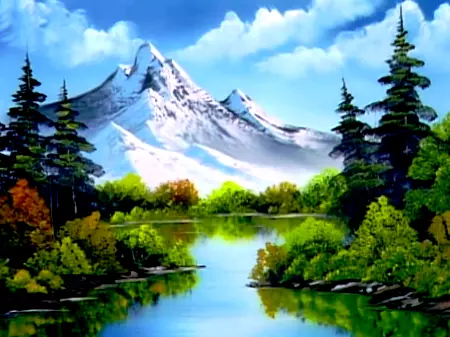

In [7]:

BOBROSS_URL = "https://github.com/PSAM-5005-2026S-A/5005-utils/raw/main/datasets/csv/bob_ross_elements.csv"
paintings = list_from_csv_url(BOBROSS_URL)

print(paintings[0])
print(paintings[1])

my_painting = paintings[145]

display(image_from_url(my_painting[2]))

In [3]:
# Always good to take a look at the data we just read
print(paintings[0])
print(paintings[1])

NameError: name 'paintings' is not defined

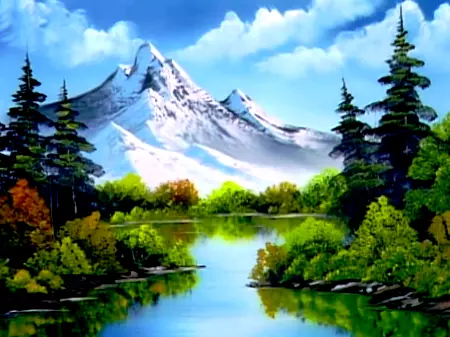

In [25]:
# The random painting
my_painting = paintings[145]
display(image_from_url(my_painting[2]))

#### Insert Distance in Dataset

Now, similar to what we did in `Homework02`, we'll go through the dataset and insert an extra column to each row with the distance from that painting to the painting we selected.

We have a function that calculates distance based on the extended euclidean formula, we just have to make sure we give it the right columns from each row (use slicing to skip the first $3$ columns).

In [ ]:
# TODO: iterate through the dataset

for painting in paintings:        
    episode = painting[1]       
    url = painting[2]             
    print(episode, url)


TITLE IMAGE_URL
A WALK IN THE WOODS https://www.twoinchbrush.com/images/painting282.webp
MT. MCKINLEY https://www.twoinchbrush.com/images/painting283.webp
EBONY SUNSET https://www.twoinchbrush.com/images/painting284.webp
WINTER MIST https://www.twoinchbrush.com/images/painting285.webp
QUIET STREAM https://www.twoinchbrush.com/images/painting286.webp
WINTER MOON https://www.twoinchbrush.com/images/painting287.webp
AUTUMN MOUNTAINS https://www.twoinchbrush.com/images/painting288.webp
PEACEFUL VALLEY https://www.twoinchbrush.com/images/painting289.webp
SEASCAPE https://www.twoinchbrush.com/images/painting290.webp
MOUNTAIN LAKE https://www.twoinchbrush.com/images/painting291.webp
WINTER GLOW https://www.twoinchbrush.com/images/painting292.webp
SNOWFALL https://www.twoinchbrush.com/images/painting293.webp
FINAL REFLECTIONS https://www.twoinchbrush.com/images/painting294.webp
MEADOW LAKE https://www.twoinchbrush.com/images/painting269.webp
WINTER SUN https://www.twoinchbrush.com/images/paint

In [10]:

# TODO: add a column to each row with its distance from my_painting
import math 

my_features = [1, 2, 3]
def feature_distance(list0, list1):
    total = 0
    for i in range(len(list0)):
        total += (list0[i] - list1[i]) ** 2
    return math.sqrt(total)

for painting in paintings:
    row_features = [1, 0, 4] 
    dist = feature_distance(my_features, row_features)
    painting.append(dist)  

print(paintings[0]) 



['EPISODE', 'TITLE', 'IMAGE_URL', 'APPLE_FRAME', 'AURORA_BOREALIS', 'BARN', 'BEACH', 'BOAT', 'BRIDGE', 'BUILDING', 'BUSHES', 'CABIN', 'CACTUS', 'CIRCLE_FRAME', 'CIRRUS', 'CLIFF', 'CLOUDS', 'CONIFER', 'CUMULUS', 'DECIDUOUS', 'DIANE_ANDRE', 'DOCK', 'DOUBLE_OVAL_FRAME', 'FARM', 'FENCE', 'FIRE', 'FLORIDA_FRAME', 'FLOWERS', 'FOG', 'FRAMED', 'GRASS', 'GUEST', 'HALF_CIRCLE_FRAME', 'HALF_OVAL_FRAME', 'HILLS', 'LAKE', 'LAKES', 'LIGHTHOUSE', 'MILL', 'MOON', 'MOUNTAIN', 'MOUNTAINS', 'NIGHT', 'OCEAN', 'OVAL_FRAME', 'PALM_TREES', 'PATH', 'PERSON', 'PORTRAIT', 'RECTANGLE_3D_FRAME', 'RECTANGULAR_FRAME', 'RIVER', 'ROCKS', 'SEASHELL_FRAME', 'SNOW', 'SNOWY_MOUNTAIN', 'SPLIT_FRAME', 'STEVE_ROSS', 'STRUCTURE', 'SUN', 'TOMB_FRAME', 'TREE', 'TREES', 'TRIPLE_FRAME', 'WATERFALL', 'WAVES', 'WINDMILL', 'WINDOW_FRAME', 'WINTER', 'WOOD_FRAMED', 2.23606797749979]


#### Sort By Distance

We can sort the paintings by the distance value we inserted in the last column of the dataset now.

The very first painting will most likely be the chosen painting, since it will have a distance of $0$ to itself.

The ones after that will have similar elements as the chosen painting.

In [14]:
# TODO: sort by the last column (index -1)

import math


paintings_by_distance = sorted(paintings, key=lambda painting: painting[-1])

# TODO: take a look at the first 5 or so paintings

closest_3 = paintings_by_distance[1:6] 

for painting in closest_3:
    print(painting[0], painting[1])

# TODO: visualize them with display(image_from_url(p[2]))

from IPython.display import display, Image

for p in closest_3:
    display(Image(url=p[2]))

S01E01 A WALK IN THE WOODS
S01E02 MT. MCKINLEY
S01E03 EBONY SUNSET
S01E04 WINTER MIST
S01E05 QUIET STREAM


### Conclusion

We'll see the Euclidean distance formula throughout the semester. It's simple to implement, but very powerful when it comes to comparing items in a dataset and calculating how "*similar*" they are.